<a href="https://colab.research.google.com/github/jess22jess/SIMULACI-N-II/blob/main/MCMC_Algoritmo_de_Metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCMC: Algoritmo de Metropolis-Hastings
Arcos Gutiérrez Jessica Beatriz

---
El algoritmo de Metropolis-Hastings genera una cadena de Markov, dónde sus estados convergen a la distribución objetivo.

**Metodología a seguir:**

* Iniciar en un punto $x_0$
 .
* Proponer un nuevo punto y usar la distribución Normal.
* Calcular la probabilidad de aceptación $\alpha = min(1, \frac{f(y)}{f(x)})$
* Aceptar o rechazar el nuevo punto.
* Repetir.


  En este apartado importamos las librerías, dónde Seaborn se está usando para generar gráficos estadísticos avanzados.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Creamos una función donde definimos el logaritmo de la función dada en clase.

In [19]:
def target_log_prob(x1, x2):
    term = -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2.0
    return term

Creamos la función de metropolis-hastings, la cuál implementa el algoritmo iterativo que genera candidatos con una caminata aleatoria, evalúa la regla de aceptación en escala logarítmica y almacena la cadena de muestras resultante.

In [20]:
def metropolis_hastings(n_samples, initial_state, proposal_std):
    x_current = np.array(initial_state, dtype=float)
    samples = np.zeros((n_samples, 2))
    samples[0] = x_current
    accepted_count = 0

    for t in range(1, n_samples):
        y_candidate = np.random.normal(loc=x_current, scale=proposal_std)
        # Calculamos la diferencia de log-probabilidades
        log_prob_current = target_log_prob(x_current[0], x_current[1])
        log_prob_candidate = target_log_prob(y_candidate[0], y_candidate[1])
        log_alpha = log_prob_candidate - log_prob_current # Regla de aceptación

        # Aceptamos si log de U es menor a log de alpha
        if np.log(np.random.rand()) < log_alpha:
            x_current = y_candidate
            accepted_count += 1

        samples[t] = x_current

    print(f"Tasa de aceptación: {accepted_count / n_samples:.2f}")
    return samples

En esta parte lo que estamos haciendo es establecer los parámetros iniciales para el algoritmo, siendo estos:
* el número total de muestras a generar **(n_samples = 50000)**
* el punto de partida de la cadena **(x0 = [1.0, 1.0])**
* la desviación estándar de la distribución propuesta **(proposal_std = 1.0)**, la cual controla qué tan grandes son los saltos en la caminata aleatoria.

In [21]:
n_samples = 50000
x0 = [1.0, 1.0]
proposal_std = 1.0

Llamamos a la función metropolis_hastings pasando los parámetros definidos anteriormente.

El algoritmo corre las 50,000 iteraciones y devuelve la matriz samples con la cadena de estados generada.

Finalmente imprimimos la tasa de aceptación, que indica la proporción de candidatos que fueron aceptados durante el proceso.

In [22]:
samples = metropolis_hastings(n_samples, x0, proposal_std)

Tasa de aceptación: 0.30


La constante de normalización c se obtiene resolviendo la integral doble de la función sin normalizar en todo el dominio, utilizando la librería scipy.integrate.

Donde su valor es aproximadamente:

In [23]:
c = 4.9465e-5

In [24]:
x = np.linspace(-1, 5, 220)
y = np.linspace(-1, 5, 220)
X, Y = np.meshgrid(x, y)

Función inicial

In [25]:
Z = c * np.exp(
    -(X**2 * Y**2 + X**2 + Y**2 - 8*X - 8*Y) / 2)

**Gráfica en 3D**

Se visualiza la función de densidad objetivo f(x,y) en un espacio tridimensional.

En esta gráfica, la superficie representa la probabilidad de la distribución original, de esta manera se nos permite entender la forma real de la distribución antes de ser muestreada por el algoritmo.

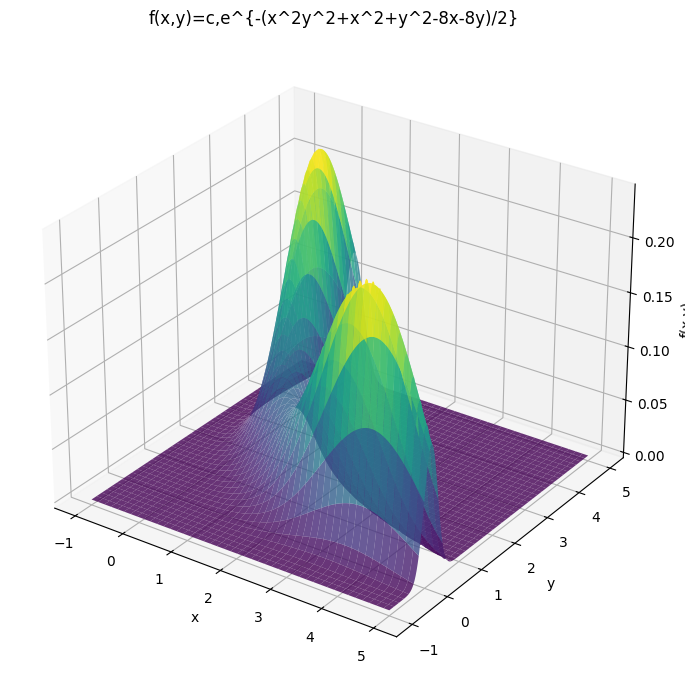

In [30]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('f(x,y)=c,e^{-(x^2y^2+x^2+y^2-8x-8y)/2}')
ax.view_init(elev=28, azim=-55)
plt.tight_layout()
plt.show()

**Gráfica de Dispersión**

Se visualizan las 50,000 muestras generadas por el algoritmo en un plano bidimensional.

 En esta gráfica los puntos azules representan los estados visitados por la cadena de Markov. Se espera que los puntos se concentren en las regiones de mayor probabilidad de la función objetivo.

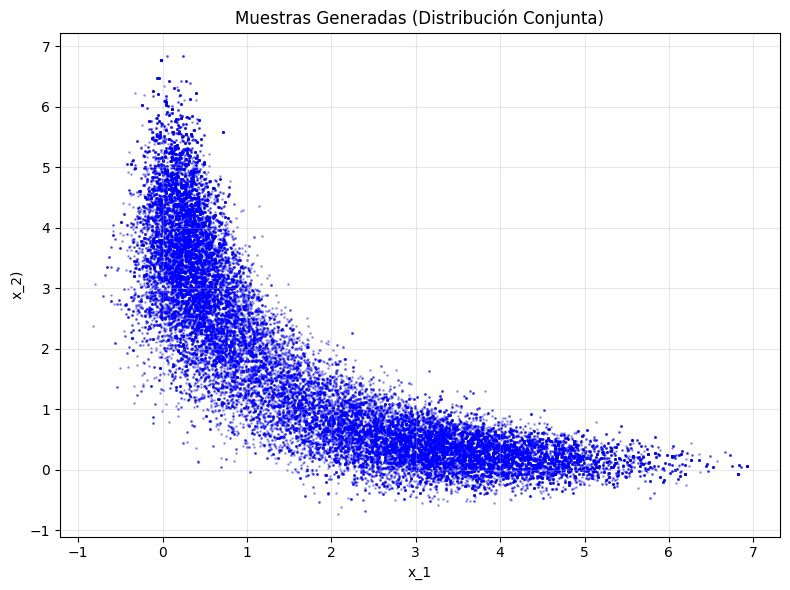

In [28]:

plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.3, c='blue')
plt.title('Muestras Generadas (Distribución Conjunta)')
plt.xlabel(r'x_1')
plt.ylabel(r'x_2)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Mapa de Calor de Densidad**

Se utiliza una estimación de densidad por núcleo (KDE) para suavizar la distribución de las muestras.

El objetivo es visualizar las curvas de nivel de probabilidad. Las zonas de color amarillo brillante indican una alta concentración de muestras (mayor probabilidad), mientras que las zonas oscuras indican menor probabilidad.

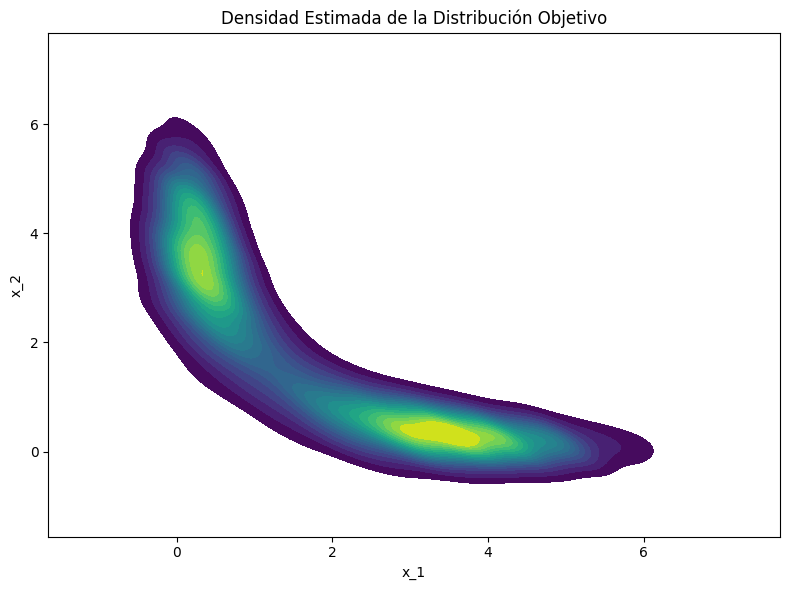

In [31]:
plt.figure(figsize=(8, 6))
sns.kdeplot(x=samples[:, 0], y=samples[:, 1], cmap="viridis", fill=True, thresh=0.05, levels=20)
plt.title('Densidad Estimada de la Distribución Objetivo')
plt.xlabel(r'x_1')
plt.ylabel(r'x_2')
plt.tight_layout()
plt.show()